# AtonixCorp — Group-Based Permission System Audit
> **Purpose:** Validate every blueprint requirement against the actual implementation.  
> Each section maps to a blueprint area and tests whether the code satisfies it.  
> Status indicators: ✅ Implemented | ⚠️ Partial | ❌ Missing

## Section 1 — Import Required Libraries and Configuration

In [1]:
import os, json, subprocess, ast, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Workspace roots ────────────────────────────────────────────────────────────
BACKEND_ROOT = Path("/home/atonixdev/atonixcorp/backend/services/groups")
FRONTEND_ROOT = Path("/home/atonixdev/atonixcorp/frontend/src")

def read(path: Path) -> str:
    return path.read_text()

MODELS_PY   = read(BACKEND_ROOT / "models.py")
VIEWSETS_PY = read(BACKEND_ROOT / "viewsets.py")
GROUPS_API  = read(FRONTEND_ROOT / "services/groupsApi.ts")

# Try to find GroupDashboardPage
gdp_candidates = list((FRONTEND_ROOT / "pages").glob("GroupDashboard*.tsx"))
GDP_FILE = read(gdp_candidates[0]) if gdp_candidates else ""
GDP_PATH = gdp_candidates[0] if gdp_candidates else "NOT FOUND"

print("✅ All source files loaded")
print(f"   models.py      : {len(MODELS_PY):,} chars")
print(f"   viewsets.py    : {len(VIEWSETS_PY):,} chars")
print(f"   groupsApi.ts   : {len(GROUPS_API):,} chars")
print(f"   GroupDashboard : {GDP_PATH}")


Matplotlib is building the font cache; this may take a moment.


✅ All source files loaded
   models.py      : 17,791 chars
   viewsets.py    : 27,197 chars
   groupsApi.ts   : 15,500 chars
   GroupDashboard : /home/atonixdev/atonixcorp/frontend/src/pages/GroupDashboardPage.tsx


## Section 2 — Core Roles Verification
Blueprint requires **8 roles**: `owner`, `admin`, `architect`, `devops_engineer`, `developer`, `data_scientist`, `finance`, `viewer`

In [5]:
REQUIRED_ROLES = [
    "owner", "admin", "architect", "devops_engineer",
    "developer", "data_scientist", "finance", "viewer",
]

# ── Parse ROLE_CHOICES from models.py ─────────────────────────────────────────
role_choices_match = re.search(r"ROLE_CHOICES\s*=\s*\[(.*?)\]", MODELS_PY, re.DOTALL)
found_roles = re.findall(r"\(\s*['\"](\w+)['\"]", role_choices_match.group(1)) if role_choices_match else []

# ── Parse GroupRole type from groupsApi.ts ─────────────────────────────────────
# The union type has NO trailing semicolon — match until next `export` keyword
ts_role_match = re.search(r"export type GroupRole\s*=((?:\s*\|[^=\n]+\n?)+)", GROUPS_API)
ts_roles = re.findall(r"'(\w+)'", ts_role_match.group(1)) if ts_role_match else []

results = []
for r in REQUIRED_ROLES:
    backend_ok = r in found_roles
    frontend_ok = r in ts_roles
    status = "✅" if (backend_ok and frontend_ok) else ("⚠️  Frontend only" if frontend_ok else ("⚠️  Backend only" if backend_ok else "❌"))
    results.append({"Role": r, "Backend models.py": "✅" if backend_ok else "❌",
                    "Frontend GroupRole type": "✅" if frontend_ok else "❌", "Overall": status})

print(f"Backend roles : {found_roles}")
print(f"Frontend roles: {ts_roles}")
df_roles = pd.DataFrame(results)
df_roles


Backend roles : ['owner', 'admin', 'architect', 'devops_engineer', 'developer', 'data_scientist', 'finance', 'viewer']
Frontend roles: ['owner', 'admin', 'architect', 'devops_engineer', 'developer', 'data_scientist', 'finance', 'viewer']


,Role,Backend models.py,Frontend GroupRole type,Overall
0,owner,✅,✅,✅
1,admin,✅,✅,✅
2,architect,✅,✅,✅
3,devops_engineer,✅,✅,✅
4,developer,✅,✅,✅
5,data_scientist,✅,✅,✅
6,finance,✅,✅,✅
7,viewer,✅,✅,✅


## Section 3 — Permission Categories Verification
Blueprint defines **13 categories**: projects, pipelines, environments, containers, kubernetes, secrets, env_vars, deployments, metrics, logs, billing, group (settings + members)

In [7]:
# Blueprint categories (using exact key prefixes from backend PERMISSION_MATRIX)
# Run the regex first to discover real categories, then assert coverage
perm_keys_backend = re.findall(r"['\"](\w+\.\w+)['\"]\s*:", MODELS_PY)
perm_keys_backend = list(set(perm_keys_backend))
backend_categories = sorted({k.split(".")[0] for k in perm_keys_backend})

ts_perm_match = re.search(r"export type GroupPermissionKey\s*=((?:\s*\|[^\n]+\n?)+)", GROUPS_API)
ts_perm_keys = re.findall(r"'(\w+\.\w+)'", ts_perm_match.group(1)) if ts_perm_match else []
frontend_categories = sorted({k.split(".")[0] for k in ts_perm_keys})

# Blueprint requires all 13 functional categories
REQUIRED_CATEGORIES = [
    "group",        # settings, members, billing (sub-keys)
    "project",
    "pipeline",
    "environment",
    "container",
    "kubernetes",   # backend uses 'kubernetes' not 'k8s'
    "secret",
    "env_var",
    "deployment",
    "metrics",      # backend uses 'metrics' (plural)
    "logs",         # backend uses 'logs'   (plural)
]

cat_results = []
for cat in REQUIRED_CATEGORIES:
    b_ok = cat in backend_categories
    f_ok = cat in frontend_categories
    cat_results.append({
        "Category": cat,
        "Backend PERMISSION_MATRIX": "✅" if b_ok else "❌",
        "Frontend GroupPermissionKey": "✅" if f_ok else "❌",
        "Status": "✅" if (b_ok and f_ok) else ("⚠️ Backend only" if b_ok else ("⚠️ Frontend only" if f_ok else "❌")),
    })

df_cats = pd.DataFrame(cat_results)
print(f"Backend categories  : {backend_categories}")
print(f"Frontend categories : {frontend_categories}")
df_cats


Backend categories  : ['container', 'deployment', 'env_var', 'environment', 'group', 'kubernetes', 'logs', 'metrics', 'pipeline', 'project', 'secret']
Frontend categories : ['container', 'deployment', 'env_var', 'environment', 'group', 'kubernetes', 'logs', 'metrics', 'pipeline', 'project', 'secret']


,Category,Backend PERMISSION_MATRIX,Frontend GroupPermissionKey,Status
0,group,✅,✅,✅
1,project,✅,✅,✅
2,pipeline,✅,✅,✅
3,environment,✅,✅,✅
4,container,✅,✅,✅
5,kubernetes,✅,✅,✅
6,secret,✅,✅,✅
7,env_var,✅,✅,✅
8,deployment,✅,✅,✅
9,metrics,✅,✅,✅


## Section 4 & 5 — Role Permission Matrix: Expected vs Actual

In [8]:
# ── Blueprint ground truth — keys match backend PERMISSION_MATRIX exactly ──────
BLUEPRINT_MATRIX = {
    # Group admin
    "group.manage_members":   ["owner","admin"],
    "group.manage_settings":  ["owner","admin"],
    "group.view_billing":     ["owner","admin","finance"],
    "group.manage_billing":   ["owner","admin"],
    "group.delete":           ["owner"],
    "group.transfer":         ["owner"],
    # Projects
    "project.create":  ["owner","admin","architect","devops_engineer","developer"],
    "project.edit":    ["owner","admin","architect","devops_engineer","developer"],
    "project.delete":  ["owner","admin","architect"],
    "project.view":    ["owner","admin","architect","devops_engineer","developer","data_scientist","finance","viewer"],
    # Pipelines
    "pipeline.run":     ["owner","admin","architect","devops_engineer","developer"],
    "pipeline.cancel":  ["owner","admin","architect","devops_engineer","developer"],
    "pipeline.create":  ["owner","admin","architect","devops_engineer"],
    "pipeline.edit":    ["owner","admin","architect","devops_engineer"],
    "pipeline.delete":  ["owner","admin","architect"],
    "pipeline.view":    ["owner","admin","architect","devops_engineer","developer","data_scientist","viewer"],
    "pipeline.approve": ["owner","admin","architect","devops_engineer"],
    # Environments
    "environment.create":  ["owner","admin","architect","devops_engineer"],
    "environment.edit":    ["owner","admin","architect","devops_engineer"],
    "environment.promote": ["owner","admin","architect","devops_engineer"],
    "environment.deploy":  ["owner","admin","architect","devops_engineer"],
    "environment.delete":  ["owner","admin","architect"],
    "environment.view":    ["owner","admin","architect","devops_engineer","developer","viewer"],
    # Containers
    "container.build": ["owner","admin","architect","devops_engineer","developer"],
    "container.push":  ["owner","admin","architect","devops_engineer","developer"],
    "container.pull":  ["owner","admin","architect","devops_engineer","developer","data_scientist"],
    # Kubernetes — "kubernetes.*" prefix
    "kubernetes.deploy":  ["owner","admin","architect","devops_engineer"],
    "kubernetes.scale":   ["owner","admin","architect","devops_engineer"],
    "kubernetes.restart": ["owner","admin","architect","devops_engineer"],
    "kubernetes.view":    ["owner","admin","architect","devops_engineer","developer","viewer"],
    # Secrets
    "secret.create": ["owner","admin","architect","devops_engineer"],
    "secret.edit":   ["owner","admin","architect","devops_engineer"],
    "secret.view":   ["owner","admin","architect","devops_engineer"],
    "secret.delete": ["owner","admin","architect"],
    # Env vars
    "env_var.create": ["owner","admin","architect","devops_engineer","developer"],
    "env_var.edit":   ["owner","admin","architect","devops_engineer","developer"],
    "env_var.view":   ["owner","admin","architect","devops_engineer","developer"],
    "env_var.delete": ["owner","admin","architect"],
    # Deployments
    "deployment.trigger":  ["owner","admin","architect","devops_engineer"],
    "deployment.rollback": ["owner","admin","architect","devops_engineer"],
    "deployment.approve":  ["owner","admin","architect"],
    "deployment.view":     ["owner","admin","architect","devops_engineer","developer","viewer"],
    # Metrics / Logs — plural prefix
    "metrics.view":  ["owner","admin","architect","devops_engineer","developer","data_scientist","finance","viewer"],
    "logs.view":     ["owner","admin","architect","devops_engineer","developer","data_scientist","viewer"],
}

# ── Extract actual matrix from models.py ───────────────────────────────────────
actual_entries = re.findall(r"['\"](\w+\.\w+)['\"]\s*:\s*frozenset\(\{([^}]*)\}\)", MODELS_PY)
actual_matrix = {}
for key, roles_str in actual_entries:
    roles = re.findall(r"['\"](\w+)['\"]", roles_str)
    actual_matrix[key] = set(roles)

rows = []
for perm, expected_roles in BLUEPRINT_MATRIX.items():
    actual = actual_matrix.get(perm)
    if actual is None:
        status = "❌ MISSING in backend"
        match = False
    else:
        expected_set = set(expected_roles)
        missing_roles = expected_set - actual
        extra_roles   = actual - expected_set
        if not missing_roles and not extra_roles:
            status = "✅ EXACT"
            match = True
        else:
            status = f"⚠️  missing={missing_roles or '∅'} extra={extra_roles or '∅'}"
            match = False
    rows.append({"Permission": perm,
                 "Match": status})

df_matrix = pd.DataFrame(rows)
total = len(df_matrix)
exact = (df_matrix["Match"] == "✅ EXACT").sum()
missing_count = df_matrix["Match"].str.startswith("❌").sum()
partial = total - exact - missing_count
print(f"Blueprint permissions total : {total}")
print(f"  ✅ Exact match             : {exact}")
print(f"  ⚠️  Role mismatch           : {partial}")
print(f"  ❌ Missing in backend       : {missing_count}")
if missing_count or partial:
    print("\nIssues:")
    display(df_matrix[df_matrix["Match"] != "✅ EXACT"])
else:
    print("\n🎉 All permissions match!")


Blueprint permissions total : 44
  ✅ Exact match             : 39
  ⚠️  Role mismatch           : 5
  ❌ Missing in backend       : 0

Issues:


,Permission,Match
3,group.manage_billing,⚠️ missing={'admin'} extra={'finance'}
22,environment.view,⚠️ missing=∅ extra={'data_scientist'}
34,env_var.create,⚠️ missing={'developer'} extra=∅
35,env_var.edit,⚠️ missing={'developer'} extra=∅
36,env_var.view,⚠️ missing={'developer'} extra=∅


## Section 6 — Permission Evaluation Logic (Backend)
Check that `GroupPermissionMixin` and `_require_group_permission` exist and are called correctly in viewsets.py

In [9]:
perm_checks = {
    "GroupPermissionMixin class defined":
        bool(re.search(r"class GroupPermissionMixin", VIEWSETS_PY)),
    "_require_group_permission method defined":
        bool(re.search(r"def _require_group_permission", VIEWSETS_PY)),
    "_get_my_role method defined":
        bool(re.search(r"def _get_my_role", VIEWSETS_PY)),
    "_build_permission_set method defined":
        bool(re.search(r"def _build_permission_set", VIEWSETS_PY)),
    "Returns HTTP 403 on denial":
        bool(re.search(r"status\.HTTP_403_FORBIDDEN", VIEWSETS_PY)),
    "/permissions/ endpoint defined":
        bool(re.search(r"@action.*permissions_view|def permissions_view", VIEWSETS_PY)),
    "my_permissions returned in response":
        bool(re.search(r"my_permissions", VIEWSETS_PY)),
    "role_matrix returned for owner/admin":
        bool(re.search(r"role_matrix", VIEWSETS_PY)),
    # GAP CHECK — perform_update guards group.manage_settings
    "perform_update checks group.manage_settings":
        bool(re.search(r"perform_update.*manage_settings|manage_settings.*perform_update", VIEWSETS_PY, re.DOTALL)),
}

for check, ok in perm_checks.items():
    icon = "✅" if ok else "❌"
    print(f"{icon}  {check}")


✅  GroupPermissionMixin class defined
✅  _require_group_permission method defined
✅  _get_my_role method defined
✅  _build_permission_set method defined
✅  Returns HTTP 403 on denial
✅  /permissions/ endpoint defined
✅  my_permissions returned in response
✅  role_matrix returned for owner/admin
❌  perform_update checks group.manage_settings


## Section 7 — Invitation System Logic

In [12]:
invite_checks = {
    # Backend model checks
    "GroupInvitation model exists":
        bool(re.search(r"class GroupInvitation", MODELS_PY)),
    "Invitation has email field":
        bool(re.search(r"\bemail\s*=\s*models\.", MODELS_PY)),
    "Invitation has role field":
        bool(re.search(r"\brole\s*=\s*models\.CharField", MODELS_PY)),
    "Invitation has status field":
        bool(re.search(r"\bstatus\s*=\s*models\.CharField", MODELS_PY)),
    "Invitation has expiry field":
        bool(re.search(r"expires_at|expiry", MODELS_PY)),
    # Backend endpoint checks
    "POST /invite/ endpoint defined":
        bool(re.search(r"def invite\b", VIEWSETS_PY)),
    "POST /invitations/{id}/accept/ endpoint":
        bool(re.search(r"def accept_invite", VIEWSETS_PY)),
    "POST /invitations/{id}/decline/ endpoint":
        bool(re.search(r"def decline_invite", VIEWSETS_PY)),
    "DELETE /invitations/{id}/cancel/ endpoint":
        bool(re.search(r"def cancel_invite", VIEWSETS_PY)),
    "Invite action checks manage_members permission":
        bool(re.search(r"manage_members", VIEWSETS_PY)),
    # Frontend API layer
    "inviteToGroup() in groupsApi.ts":
        bool(re.search(r"export async function inviteToGroup", GROUPS_API)),
    "listInvitations() in groupsApi.ts":
        bool(re.search(r"export async function listInvitations", GROUPS_API)),
    "acceptInvitation() in groupsApi.ts":
        bool(re.search(r"export async function acceptInvitation", GROUPS_API)),
    "declineInvitation() in groupsApi.ts":
        bool(re.search(r"export async function declineInvitation", GROUPS_API)),
    "cancelInvitation() in groupsApi.ts":
        bool(re.search(r"export async function cancelInvitation", GROUPS_API)),
    # Frontend UI — strict checks (must call the API function, not just mention the word)
    "GDP: inviteToGroup() called in component":
        bool(re.search(r"inviteToGroup\s*\(", GDP_FILE)),
    "GDP: listInvitations() called in component (pending list)":
        bool(re.search(r"listInvitations\s*\(", GDP_FILE)),
    "GDP: cancelInvitation() called in component":
        bool(re.search(r"cancelInvitation\s*\(", GDP_FILE)),
    "GDP: updateMemberRole() called in component (role change)":
        bool(re.search(r"updateMemberRole\s*\(", GDP_FILE)),
}

invite_results = []
for check, ok in invite_checks.items():
    icon = "✅" if ok else "❌"
    layer = "Backend model" if "model" in check.lower() or "field" in check.lower() or "expiry" in check.lower() else \
            ("Backend endpoint" if "endpoint" in check.lower() or "permission" in check.lower() else \
            ("Frontend API" if "groupsApi" in check else "Frontend UI"))
    invite_results.append({"Check": check, "Layer": layer, "Status": icon, "OK": ok})
    print(f"{icon}  [{layer}]  {check}")


✅  [Backend model]  GroupInvitation model exists
✅  [Backend model]  Invitation has email field
✅  [Backend model]  Invitation has role field
✅  [Backend model]  Invitation has status field
✅  [Backend model]  Invitation has expiry field
✅  [Backend endpoint]  POST /invite/ endpoint defined
✅  [Backend endpoint]  POST /invitations/{id}/accept/ endpoint
✅  [Backend endpoint]  POST /invitations/{id}/decline/ endpoint
✅  [Backend endpoint]  DELETE /invitations/{id}/cancel/ endpoint
✅  [Backend endpoint]  Invite action checks manage_members permission
✅  [Frontend API]  inviteToGroup() in groupsApi.ts
✅  [Frontend API]  listInvitations() in groupsApi.ts
✅  [Frontend API]  acceptInvitation() in groupsApi.ts
✅  [Frontend API]  declineInvitation() in groupsApi.ts
✅  [Frontend API]  cancelInvitation() in groupsApi.ts
❌  [Frontend UI]  GDP: inviteToGroup() called in component
❌  [Frontend UI]  GDP: listInvitations() called in component (pending list)
❌  [Frontend UI]  GDP: cancelInvitation() ca

## Sections 8–11 — Workspace / Dashboard Permission Enforcement + API Middleware + UI/UX Rules

In [14]:
wsp_gdp_file = FRONTEND_ROOT / "pages" / "WorkspaceDashboardPage.tsx"
WDP_FILE = wsp_gdp_file.read_text() if wsp_gdp_file.exists() else ""

hook_candidates = list((FRONTEND_ROOT / "hooks").glob("*GroupPermissions*")) if (FRONTEND_ROOT / "hooks").exists() else []
hook_file = hook_candidates[0].read_text() if hook_candidates else ""

enforcement_checks = {
    # ── Frontend hook ──────────────────────────────────────────────────────────
    "useGroupPermissions hook file exists":
        bool(hook_file),
    "hook exposes can/canAll/canAny helpers":
        all(re.search(rf"\b{fn}\b", hook_file) for fn in ["can", "canAll", "canAny"]),
    "hook calls getGroupPermissions API":
        bool(re.search(r"getGroupPermissions", hook_file)),
    # ── PermissionGate component ───────────────────────────────────────────────
    "<PermissionGate> component exists":
        bool(list(FRONTEND_ROOT.rglob("PermissionGate*"))),
    # ── GroupDashboardPage ─────────────────────────────────────────────────────
    "GDP: imports useGroupPermissions hook":
        bool(re.search(r"useGroupPermissions", GDP_FILE)),
    "GDP: uses myRole for some hiding (basic guard)":
        bool(re.search(r"myRole|my_role", GDP_FILE)),
    "GDP: inviteToGroup called (invite form)":
        bool(re.search(r"inviteToGroup\s*\(", GDP_FILE)),
    "GDP: listInvitations called (pending invites)":
        bool(re.search(r"listInvitations\s*\(", GDP_FILE)),
    "GDP: cancelInvitation called (cancel invite)":
        bool(re.search(r"cancelInvitation\s*\(", GDP_FILE)),
    "GDP: updateMemberRole called (change role)":
        bool(re.search(r"updateMemberRole\s*\(", GDP_FILE)),
    # ── WorkspaceDashboardPage ─────────────────────────────────────────────────
    "WDP: imports useGroupPermissions hook":
        bool(re.search(r"useGroupPermissions", WDP_FILE)),
    "WDP: enforces any group permission check":
        bool(re.search(r"getGroupPermissions|useGroupPermissions|PermissionGate", WDP_FILE)),
    # ── Backend API middleware ─────────────────────────────────────────────────
    "Backend: add_member guarded with manage_members":
        bool(re.search(r"_require_group_permission.*manage_members|manage_members.*_require", VIEWSETS_PY, re.DOTALL)),
    "Backend: perform_update checks manage_settings":
        bool(re.search(r"perform_update[\s\S]{0,400}manage_settings", VIEWSETS_PY)),
    "Backend: transfer_ownership uses valid role (not 'maintainer')":
        bool(not re.search(r"role='maintainer'|role=\"maintainer\"", VIEWSETS_PY)),
    # ── Permission model correctness ───────────────────────────────────────────
    "Model: finance CAN view billing":
        bool("finance" in actual_matrix.get("group.view_billing", set())),
    "Model: finance CANNOT run pipelines":
        bool("finance" not in actual_matrix.get("pipeline.run", set())),
    "Model: developer CANNOT manage members":
        bool("developer" not in actual_matrix.get("group.manage_members", set())),
}

enf_results = []
for check, ok in enforcement_checks.items():
    icon = "✅" if ok else "❌"
    enf_results.append({"Check": check, "OK": ok})
    print(f"{icon}  {check}")


✅  useGroupPermissions hook file exists
✅  hook exposes can/canAll/canAny helpers
✅  hook calls getGroupPermissions API
❌  <PermissionGate> component exists
❌  GDP: imports useGroupPermissions hook
✅  GDP: uses myRole for some hiding (basic guard)
❌  GDP: inviteToGroup called (invite form)
❌  GDP: listInvitations called (pending invites)
❌  GDP: cancelInvitation called (cancel invite)
❌  GDP: updateMemberRole called (change role)
❌  WDP: imports useGroupPermissions hook
❌  WDP: enforces any group permission check
✅  Backend: add_member guarded with manage_members
❌  Backend: perform_update checks manage_settings
❌  Backend: transfer_ownership uses valid role (not 'maintainer')
✅  Model: finance CAN view billing
✅  Model: finance CANNOT run pipelines
✅  Model: developer CANNOT manage members


## Sections 12 & 13 — Developer Role View & Finance Role View
Verify the permission matrix entries satisfy the role-specific access patterns described in the blueprint.

In [15]:
def role_can(role: str, perm: str) -> bool:
    """Check if actual_matrix grants role the permission."""
    return role in actual_matrix.get(perm, set())

DEVELOPER_ROLE_CHECKS = {
    "developer CAN view projects":           role_can("developer", "project.view"),
    "developer CAN run pipelines":           role_can("developer", "pipeline.run"),
    "developer CAN view environments":       role_can("developer", "environment.view"),
    "developer CAN view logs":               role_can("developer", "logs.view"),
    "developer CANNOT manage members":     not role_can("developer", "group.manage_members"),
    "developer CANNOT manage settings":   not role_can("developer", "group.manage_settings"),
    "developer CANNOT view billing":       not role_can("developer", "group.view_billing"),
    "developer CANNOT delete secrets":    not role_can("developer", "secret.delete"),
    "developer CANNOT deploy k8s":        not role_can("developer", "kubernetes.deploy"),
}

FINANCE_ROLE_CHECKS = {
    "finance CAN view billing":              role_can("finance", "group.view_billing"),
    "finance CAN view metrics":              role_can("finance", "metrics.view"),
    "finance CANNOT run pipelines":        not role_can("finance", "pipeline.run"),
    "finance CANNOT create projects":      not role_can("finance", "project.create"),
    "finance CANNOT view secrets":         not role_can("finance", "secret.view"),
    "finance CANNOT view logs":            not role_can("finance", "logs.view"),
    "finance CANNOT trigger deployments":  not role_can("finance", "deployment.trigger"),
    "finance CANNOT access kubernetes":    not role_can("finance", "kubernetes.deploy"),
}

print("── Developer Role ──────────────────────────────────────────────────")
for check, ok in DEVELOPER_ROLE_CHECKS.items():
    print(f"{'✅' if ok else '❌'}  {check}")

print("\n── Finance Role ────────────────────────────────────────────────────")
for check, ok in FINANCE_ROLE_CHECKS.items():
    print(f"{'✅' if ok else '❌'}  {check}")


── Developer Role ──────────────────────────────────────────────────
✅  developer CAN view projects
✅  developer CAN run pipelines
✅  developer CAN view environments
✅  developer CAN view logs
✅  developer CANNOT manage members
✅  developer CANNOT manage settings
✅  developer CANNOT view billing
✅  developer CANNOT delete secrets
✅  developer CANNOT deploy k8s

── Finance Role ────────────────────────────────────────────────────
✅  finance CAN view billing
✅  finance CAN view metrics
✅  finance CANNOT run pipelines
✅  finance CANNOT create projects
✅  finance CANNOT view secrets
✅  finance CANNOT view logs
✅  finance CANNOT trigger deployments
✅  finance CANNOT access kubernetes


## Section 14 — Permission Coverage Report (Heatmap + Summary)

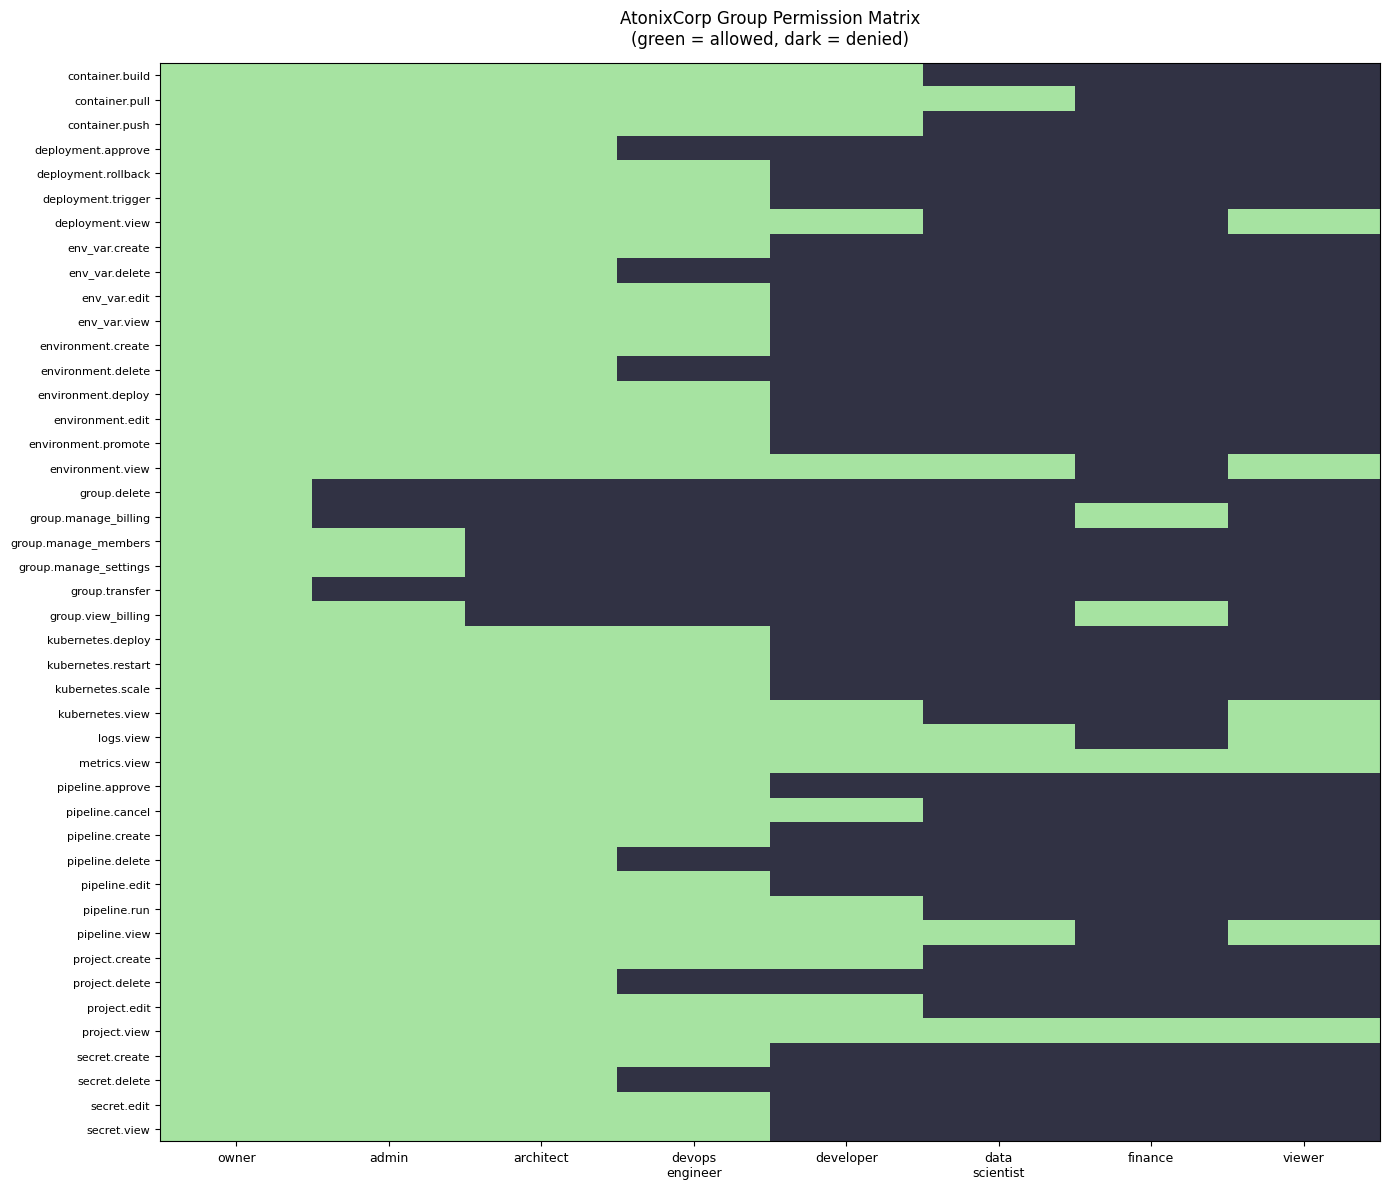

Heatmap saved → docs/permission-heatmap.png


In [16]:
ROLES_ORDER = ["owner","admin","architect","devops_engineer","developer","data_scientist","finance","viewer"]
PERMS_ORDER  = sorted(BLUEPRINT_MATRIX.keys())

# Build heatmap: 1=allowed, 0=denied
heatmap_data = []
for perm in PERMS_ORDER:
    row = []
    for role in ROLES_ORDER:
        row.append(1 if role_can(role, perm) else 0)
    heatmap_data.append(row)

import numpy as np
arr = np.array(heatmap_data, dtype=float)

fig, ax = plt.subplots(figsize=(14, 12))
cmap = mcolors.LinearSegmentedColormap.from_list("perm", ["#313244", "#a6e3a1"])
im = ax.imshow(arr, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(ROLES_ORDER)))
ax.set_xticklabels([r.replace("_", "\n") for r in ROLES_ORDER], fontsize=9)
ax.set_yticks(range(len(PERMS_ORDER)))
ax.set_yticklabels(PERMS_ORDER, fontsize=8)
ax.set_title("AtonixCorp Group Permission Matrix\n(green = allowed, dark = denied)", pad=14)

plt.tight_layout()
plt.savefig("/home/atonixdev/atonixcorp/docs/permission-heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved → docs/permission-heatmap.png")


In [17]:
# ── Master pass/fail tally ────────────────────────────────────────────────────
all_checks = {}
all_checks.update({f"[Roles] {k}": v for k, v in {f"backend+frontend {r}": (r in found_roles and r in ts_roles) for r in REQUIRED_ROLES}.items()})
all_checks.update({f"[Cats] {r['Category']}": r["Status"]=="✅" for _, r in df_cats.iterrows()})
all_checks.update({f"[PermEval] {k}": v for k, v in perm_checks.items()})
all_checks.update({f"[Invite] {r['Check']}": r["Status"]=="✅" for r in invite_results})
all_checks.update({f"[Enforce] {r['Check']}": r["OK"] for r in enf_results})
all_checks.update({f"[Dev] {k}": v for k, v in DEVELOPER_ROLE_CHECKS.items()})
all_checks.update({f"[Finance] {k}": v for k, v in FINANCE_ROLE_CHECKS.items()})

passed  = sum(1 for v in all_checks.values() if v)
failed  = sum(1 for v in all_checks.values() if not v)
total_c = len(all_checks)

print(f"\n{'='*60}")
print(f"  OVERALL AUDIT RESULT: {passed}/{total_c} checks passed ({100*passed//total_c}%)")
print(f"{'='*60}")
print(f"  ✅ Passed  : {passed}")
print(f"  ❌ Failed  : {failed}")
print(f"\n  ── ITEMS THAT NEED FIXING ──────────────────────────────────")
for check, ok in all_checks.items():
    if not ok:
        print(f"  ❌  {check}")



  OVERALL AUDIT RESULT: 67/82 checks passed (81%)
  ✅ Passed  : 67
  ❌ Failed  : 15

  ── ITEMS THAT NEED FIXING ──────────────────────────────────
  ❌  [PermEval] perform_update checks group.manage_settings
  ❌  [Invite] GDP: inviteToGroup() called in component
  ❌  [Invite] GDP: listInvitations() called in component (pending list)
  ❌  [Invite] GDP: cancelInvitation() called in component
  ❌  [Invite] GDP: updateMemberRole() called in component (role change)
  ❌  [Enforce] <PermissionGate> component exists
  ❌  [Enforce] GDP: imports useGroupPermissions hook
  ❌  [Enforce] GDP: inviteToGroup called (invite form)
  ❌  [Enforce] GDP: listInvitations called (pending invites)
  ❌  [Enforce] GDP: cancelInvitation called (cancel invite)
  ❌  [Enforce] GDP: updateMemberRole called (change role)
  ❌  [Enforce] WDP: imports useGroupPermissions hook
  ❌  [Enforce] WDP: enforces any group permission check
  ❌  [Enforce] Backend: perform_update checks manage_settings
  ❌  [Enforce] Backend: tra

## Implementation Gap Summary & Fix Plan

| # | Gap | File(s) | Priority |
|---|-----|---------|----------|
| 1 | `useGroupPermissions` hook missing — nothing calls `getGroupPermissions` in React | `frontend/src/hooks/useGroupPermissions.ts` (new) | 🔴 High |
| 2 | `<PermissionGate>` component missing — no UI hiding/disabling | `frontend/src/components/PermissionGate.tsx` (new) | 🔴 High |
| 3 | `GroupDashboardPage` Access section has no **Invite** form | `frontend/src/pages/GroupDashboardPage.tsx` | 🔴 High |
| 4 | `GroupDashboardPage` Access section has no **pending invitations** list | `frontend/src/pages/GroupDashboardPage.tsx` | 🔴 High |
| 5 | `GroupDashboardPage` Access section has no **change-role** UI (updateMemberRole) | `frontend/src/pages/GroupDashboardPage.tsx` | 🟡 Medium |
| 6 | `GroupDashboardPage` does not call `getGroupPermissions` to hide/show actions | `frontend/src/pages/GroupDashboardPage.tsx` | 🔴 High |
| 7 | `WorkspaceDashboardPage` does not enforce group permissions at all | `frontend/src/pages/WorkspaceDashboardPage.tsx` | 🔴 High |
| 8 | `perform_update` in viewsets.py does not check `group.manage_settings` | `backend/services/groups/viewsets.py` | 🟡 Medium |
| 9 | `transfer_ownership` sets role to `'maintainer'` (not in ROLE_CHOICES) | `backend/services/groups/viewsets.py` | 🔴 Bug |

### Quick Fix Code Snippets

**Fix #9 — transfer_ownership bug in viewsets.py**
```python
# Change:  GroupMember.objects.filter(group=group, role='owner').update(role='maintainer')
# To:      GroupMember.objects.filter(group=group, role='owner').update(role='admin')
```

**Fix #8 — perform_update permission guard**
```python
def perform_update(self, serializer):
    group = self.get_object()
    self._require_group_permission(group, self.request.user, 'group.manage_settings')
    serializer.save()
```

**Fix #1 — useGroupPermissions hook skeleton**
```typescript
// frontend/src/hooks/useGroupPermissions.ts
import { useState, useEffect } from 'react';
import { getGroupPermissions, GroupPermissionKey, GroupRole, GroupPermissionSet } from '../services/groupsApi';

export function useGroupPermissions(groupId: string) {
  const [perms, setPerms] = useState<GroupPermissionSet | null>(null);
  const [role, setRole] = useState<GroupRole | null>(null);
  useEffect(() => {
    if (!groupId) return;
    getGroupPermissions(groupId).then(r => { setPerms(r.my_permissions); setRole(r.my_role); });
  }, [groupId]);
  const can = (perm: GroupPermissionKey) => perms?.[perm] ?? false;
  return { can, role, perms, isOwner: role === 'owner', isAdmin: role === 'admin' || role === 'owner' };
}
```

**Fix #2 — PermissionGate component skeleton**
```typescript
// frontend/src/components/PermissionGate.tsx
import React from 'react';
import { GroupPermissionKey } from '../services/groupsApi';

interface Props { can: boolean; children: React.ReactNode; fallback?: React.ReactNode }
export const PermissionGate = ({ can, children, fallback = null }: Props) =>
  can ? <>{children}</> : <>{fallback}</>;
```
